# Analyse


In [1]:
from pathlib import Path
import os
import time

import numpy as np
import math
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scikit_posthocs as sp

from imfcsoutputhandlerlib.core.all_image import AllImage
from imfcsoutputhandlerlib.core.image_queries import (
    get_total_num_cell,
    get_array_intensity,
    get_array_parameter_map,
    get_list_of_file_id,
    get_cfs_related,
    get_lagtimes,
)

In [2]:
DIRNAME = "input/input_sophie"
DIRNAME_OUTPUT = "output/output_sophie"

PICKLE_DATABASE_FILENAME = "all-image-database_20260109_172738.pkl"
IS_SAVE_PLOT = False
IS_SAVE_CSV = False

In [3]:
current_dir = Path().resolve()
input_path = Path(os.path.join(current_dir.parent, DIRNAME))
output_path = Path(os.path.join(current_dir.parent, DIRNAME_OUTPUT))

Load database


In [4]:
time_start = time.time()
all_image_instance = AllImage.from_pickle(
    Path(os.path.join(input_path, PICKLE_DATABASE_FILENAME))
)
time_elapsed = time.time() - time_start
print(f"time taken to load database: {time_elapsed:.3f} s")

Missing 'new_method'. Added default implementation.
time taken to load database: 0.709 s


In [5]:
all_image_instance.get_list_of_image()[0]

ImageInfo(key=tirfmh29_250926_05_w1_cell1_N27BCD-BSA_DiI-500nM-10min_561nm_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome, associated_files=['tirfmh29_250926_05_w1_cell1_N27BCD-BSA_DiI-500nM-10min_561nm_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome_pt1.xlsx', 'tirfmh29_250926_05_w1_cell1_N27BCD-BSA_DiI-500nM-10min_561nm_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome_AVR.tif'], rect_coordinates=None, is_roi_selected=None)

In [6]:
time_start = time.time()
array_average_intensity_all = get_array_intensity(all_image_instance)
array_parameter_map_all = get_array_parameter_map(all_image_instance)
list_basename_all = get_list_of_file_id(all_image_instance)
array_lagtimes = get_lagtimes(all_image_instance)
array_acf1 = get_cfs_related(all_image_instance, var="acf1")
array_sd1 = get_cfs_related(all_image_instance, var="sd1")
array_fit1 = get_cfs_related(all_image_instance, var="fit1")

time_elapsed = time.time() - time_start
print(f"time loading array from AllImage instance: {time_elapsed:.2f} s")

time loading array from AllImage instance: 2.81 s


In [7]:
print(f"Total number of cells: {get_total_num_cell(all_image_instance)}")
print(
    f"shape intensity single cell: {get_array_intensity(all_image_instance, 0).shape}"
)
print(f"shape intensity all cell: {array_average_intensity_all.shape}")
print(
    f"all key {len(get_list_of_file_id(all_image_instance))}: {get_list_of_file_id(all_image_instance)}"
)
print(f"get p map single cell: {get_array_parameter_map(all_image_instance, 0).shape}")
print(f"get pmap all cell: {array_parameter_map_all.shape}")
print(f"get acf1 all cell: {array_acf1.shape}")
print(f"get sd1 all cell: {array_sd1.shape}")
print(f"get fit1 all cell: {array_fit1.shape}")
print(f"get lagtimes all cell: {array_lagtimes.shape}")

Total number of cells: 27
shape intensity single cell: (4000, 96, 96)
shape intensity all cell: (27, 4000, 96, 96)
all key 27: ['tirfmh29_250926_05_w1_cell1_N27BCD-BSA_DiI-500nM-10min_561nm_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome', 'tirfmh29_250926_07_w1_cell2_N27BCD-BSA_DiI-500nM-10min_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome', 'tirfmh29_250926_09_w1_cell3_N27BCD-BSA_DiI-500nM-10min_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome', 'tirfmh29_250926_11_w1_cell4_N27BCD-BSA_DiI-500nM-10min_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome', 'tirfmh29_250926_13_w1_cell5_N27BCD-BSA_DiI-500nM-10min_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome', 'tirfmh29_250926_15_w2_cell1_N27BCD-SA_DiI-500nM-10min_561nm_640uW_pTIRF_p100_a71d34_x80y80w96h96_40k_fps238d1_bin2_1_point-TIRF-561.ome', 'tirfmh29_250926_17_w2_cell

Set threshold for reasonable diffusion coefficient and region for analysis


In [8]:
CENTRAL_FRACTION = 0.4
D_THRESHOLD = (0.02, 20)

Show TIRF images


In [9]:
def get_central_region(image, center_fraction=0.8):
    """
    Extracts the min-max range based on the central fraction of the image.

    Parameters:
    - image: 2D NumPy array
    - center_fraction: Fraction of the image (default is 30% or 0.3)

    Returns:
    - (min_value, max_value) for dynamic contrast scaling
    """

    assert len(image.shape) == 2, "input image must be 2D"

    h, w = image.shape
    ch, cw = int(h * center_fraction), int(w * center_fraction)  # Central region size
    y_start, x_start = (h - ch) // 2, (w - cw) // 2  # Start indices

    # Extract the central region
    central_region = image[y_start : y_start + ch, x_start : x_start + cw]

    return central_region

In [10]:
def plot_first_frames(array: np.array, list_basename: list[str]):

    num_files, n, w, h = array.shape

    if num_files == 0:
        print("No matching TIFF files found.")
        return

    # Initialize lists to store intensity values for each group
    intensities_group1 = []  # N27BCD, BSA
    intensities_group2 = []  # N27BCD, SA
    intensities_group3 = []  # N27BCD, OA
    intensities_group4 = []  # N27BCD, ALA

    intensities_group5 = []  # CLU468, BSA
    intensities_group6 = []  # CLU468, SA
    intensities_group7 = []  # CLU468, OA
    intensities_group8 = []  # CLU468, ALA

    # Determine the layout for subplots (e.g., 2x3 for 6 images)
    cols = math.ceil(math.sqrt(num_files))
    rows = math.ceil(num_files / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    axes = axes.flatten()  # Flatten in case of a 2D array of axes

    array_average_intensity_first_frame = np.zeros((num_files, w, h))

    x_roi, y_roi = get_central_region(
        array_average_intensity_first_frame[0], center_fraction=CENTRAL_FRACTION
    ).shape
    print(f"number of pixels: {x_roi * y_roi}, {x_roi=} {y_roi=}")

    for idx, file in enumerate(list_basename):

        # Read the first frame (assuming it's the first page in the TIFF file)
        array_average_intensity_first_frame[idx, :, :] = array[idx, 0, :, :]

        # Compute min and max values from the central region
        central_region = get_central_region(
            array_average_intensity_first_frame[idx], center_fraction=CENTRAL_FRACTION
        )  # Get dynamic range
        min_value, max_value = np.nanmin(central_region), np.nanmax(
            central_region
        )  # Handle NaNs

        # Plot the first frame
        ax = axes[idx]
        ax.imshow(
            array_average_intensity_first_frame[idx],
            cmap="gray",
            vmin=min_value,
            vmax=max_value,
        )
        ax.axis("off")

        # Check if 'N27BCD' is in the filename and draw a red border if so
        if "N27BCD" in file:
            # Add a red rectangle as a border
            rect = Rectangle(
                (0, 0),
                1,
                1,
                transform=ax.transAxes,
                linewidth=2.5,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)

        # Check if 'CLU468' is in the filename and draw a blue border if so
        if "CLU468" in file:
            # Add a red rectangle as a border
            rect = Rectangle(
                (0, 0),
                1,
                1,
                transform=ax.transAxes,
                linewidth=2.5,
                edgecolor="blue",
                facecolor="none",
            )
            ax.add_patch(rect)

        # Extract central region
        central_region = get_central_region(
            array_average_intensity_first_frame[idx], center_fraction=CENTRAL_FRACTION
        )  # Get dynamic range

        # Calculate mean intensity of the central region
        mean_intensity = np.nanmean(central_region)

        # Categorize based on filename
        if "N27BCD" in file:
            if "BSA" in file:
                intensities_group1.append(mean_intensity)
            elif "SA" in file:
                intensities_group2.append(mean_intensity)
            elif "OA" in file:
                intensities_group3.append(mean_intensity)
            elif "ALA" in file:
                intensities_group4.append(mean_intensity)

        if "CLU468" in file:
            if "BSA" in file:
                intensities_group5.append(mean_intensity)
            elif "SA" in file:
                intensities_group6.append(mean_intensity)
            elif "OA" in file:
                intensities_group7.append(mean_intensity)
            elif "ALA" in file:
                intensities_group8.append(mean_intensity)

    # Create corresponding group labels
    labels_group1 = ["N27BCD & BSA"] * len(intensities_group1)
    labels_group2 = ["N27BCD & SA"] * len(intensities_group2)
    labels_group3 = ["N27BCD & OA"] * len(intensities_group3)
    labels_group4 = ["N27BCD & ALA"] * len(intensities_group4)

    labels_group5 = ["CLU468 & BSA"] * len(intensities_group5)
    labels_group6 = ["CLU468 & SA"] * len(intensities_group6)
    labels_group7 = ["CLU468 & OA"] * len(intensities_group7)
    labels_group8 = ["CLU468 & ALA"] * len(intensities_group8)

    # Combine intensities and labels
    intensities = (
        intensities_group1
        + intensities_group2
        + intensities_group3
        + intensities_group4
        + intensities_group5
        + intensities_group6
        + intensities_group7
        + intensities_group8
    )
    labels = (
        labels_group1
        + labels_group2
        + labels_group3
        + labels_group4
        + labels_group5
        + labels_group6
        + labels_group7
        + labels_group8
    )

    # Create a DataFrame
    df = pd.DataFrame({"Group": labels, "Intensity": intensities})

    # Perform pairwise t-tests
    pairwise_results = sp.posthoc_ttest(
        df, val_col="Intensity", group_col="Group", p_adjust="bonferroni"
    )
    print(f"pariwise t-test results: {pairwise_results}")

    plt.figure(figsize=(10, 4))
    sns.boxplot(x="Group", y="Intensity", data=df, showfliers=False)
    sns.stripplot(x="Group", y="Intensity", data=df, color="black", jitter=0.1, size=5)

    for ax in axes[num_files:]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

number of pixels: 1444, x_roi=38 y_roi=38
pariwise t-test results:               N27BCD & BSA  N27BCD & SA  N27BCD & OA  N27BCD & ALA  \
N27BCD & BSA           1.0          1.0          1.0           1.0   
N27BCD & SA            1.0          1.0          1.0           1.0   
N27BCD & OA            1.0          1.0          1.0           1.0   
N27BCD & ALA           1.0          1.0          1.0           1.0   
CLU468 & BSA           1.0          1.0          1.0           1.0   
CLU468 & SA            1.0          1.0          1.0           1.0   
CLU468 & OA            1.0          1.0          1.0           1.0   
CLU468 & ALA           1.0          1.0          1.0           1.0   

              CLU468 & BSA  CLU468 & SA  CLU468 & OA  CLU468 & ALA  
N27BCD & BSA           1.0          1.0          1.0           1.0  
N27BCD & SA            1.0          1.0          1.0           1.0  
N27BCD & OA            1.0          1.0          1.0           1.0  
N27BCD & ALA           1.0

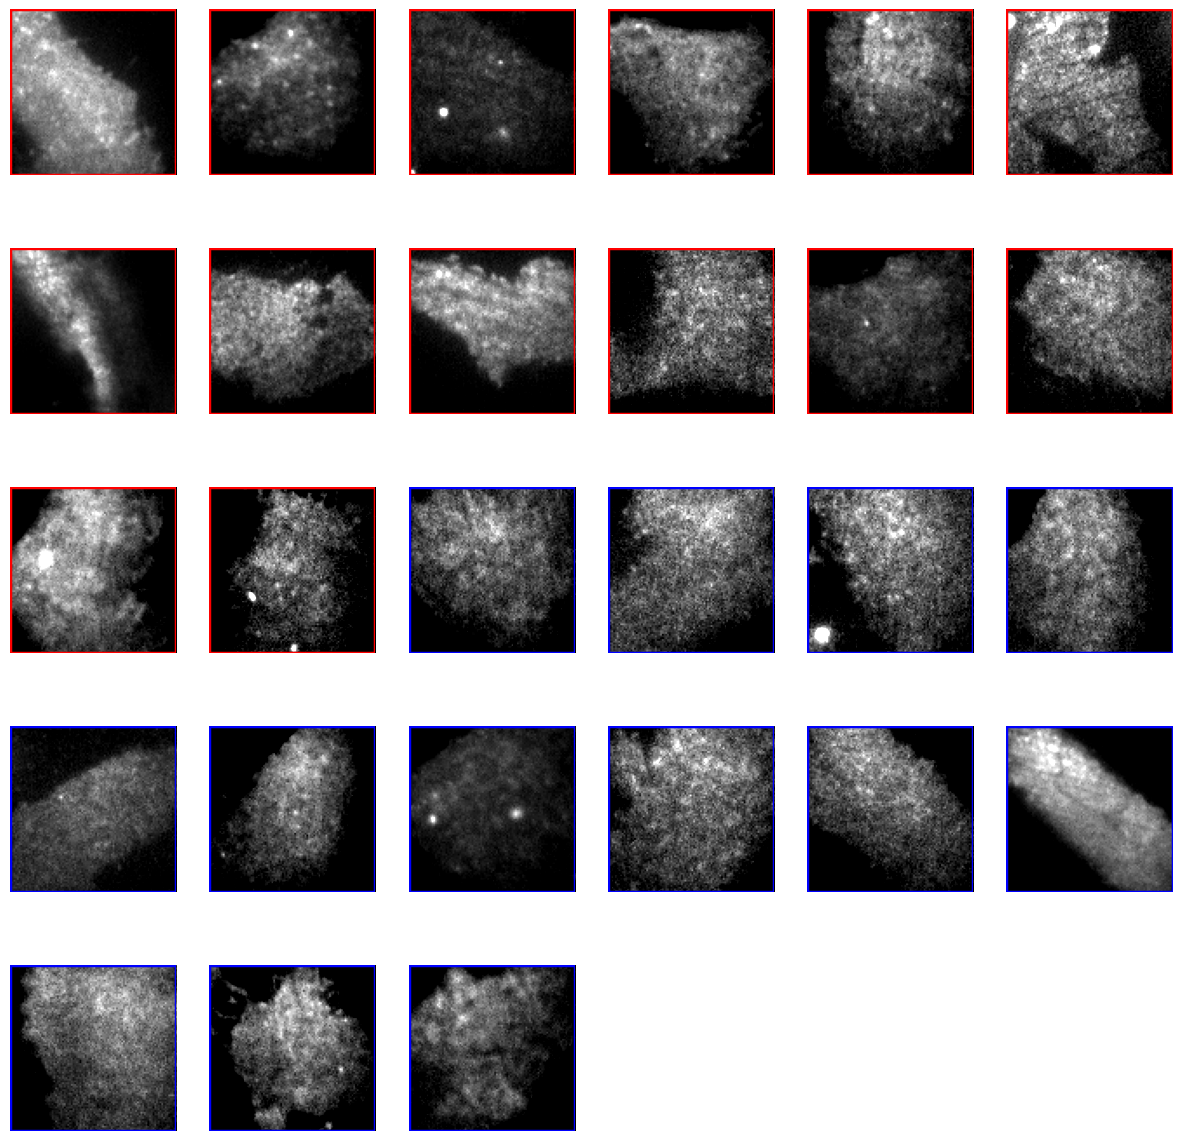

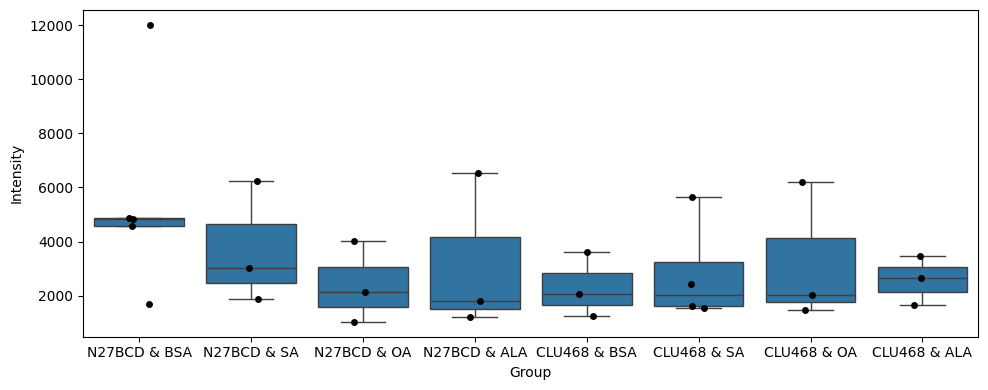

In [11]:
plot_first_frames(array=array_average_intensity_all, list_basename=list_basename_all)

In [12]:
array_average_intensity_all.shape

(27, 4000, 96, 96)

In [13]:
len(list_basename_all)

27

Show D map


In [14]:
def plot_d_values(
    param_array: np.array,
    list_basename: list[str],
    mode: int,
    PARAM=None,
    title_suffix: str = None,
    central_fraction: float = 0.8,
):
    """
    Reads all parameter array storing all 15x parameter map for each cell and compare diffusion values
    """

    num_files, w, h = param_array.shape

    # Initialize lists to store intensity values for each group
    param_group1 = []  # N27BCD, BSA
    param_group2 = []  # N27BCD, SA
    param_group3 = []  # N27BCD, OA
    param_group4 = []  # N27BCD, ALA

    param_group5 = []  # CLU468, BSA
    param_group6 = []  # CLU468, SA
    param_group7 = []  # CLU468, OA
    param_group8 = []  # CLU468, ALA

    # Determine the layout for subplots (e.g., 2x3 for 6 images)
    cols = math.ceil(math.sqrt(num_files))
    rows = math.ceil(num_files / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
    axes = axes.flatten()  # Flatten in case of a 2D array of axes

    for idx, file in enumerate(list_basename):

        p_map = param_array[idx, :, :]

        # Extract central region
        central_region = get_central_region(
            p_map, center_fraction=central_fraction
        )  # Get dynamic range
        min_value, max_value = np.nanmin(central_region), np.nanmax(
            central_region
        )  # Handle NaNs

        # Plot parameter map
        ax = axes[idx]
        ax.imshow(p_map, cmap="inferno", vmin=min_value, vmax=max_value)
        ax.axis("off")

        # Check if 'N27BCD' is in the filename and draw a red border if so
        if "N27BCD" in file:
            # Add a red rectangle as a border
            rect = Rectangle(
                (0, 0),
                1,
                1,
                transform=ax.transAxes,
                linewidth=2.5,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)

        # Check if 'CLU468' is in the filename and draw a blue border if so
        if "CLU468" in file:
            # Add a red rectangle as a border
            rect = Rectangle(
                (0, 0),
                1,
                1,
                transform=ax.transAxes,
                linewidth=2.5,
                edgecolor="blue",
                facecolor="none",
            )
            ax.add_patch(rect)

        # Calculate mean paremeter of the central region
        mean_parameter = np.nanmean(central_region)

        # Categorize based on filename
        if "N27BCD" in file:
            if "BSA" in file:
                param_group1.append(mean_parameter)
            elif "SA" in file:
                param_group2.append(mean_parameter)
            elif "OA" in file:
                param_group3.append(mean_parameter)
            elif "ALA" in file:
                param_group4.append(mean_parameter)

        if "CLU468" in file:
            if "BSA" in file:
                param_group5.append(mean_parameter)
            elif "SA" in file:
                param_group6.append(mean_parameter)
            elif "OA" in file:
                param_group7.append(mean_parameter)
            elif "ALA" in file:
                param_group8.append(mean_parameter)

    # Create corresponding group labels
    labels_group1 = ["N27BCD & BSA"] * len(param_group1)
    labels_group2 = ["N27BCD & SA"] * len(param_group2)
    labels_group3 = ["N27BCD & OA"] * len(param_group3)
    labels_group4 = ["N27BCD & ALA"] * len(param_group4)

    labels_group5 = ["CLU468 & BSA"] * len(param_group5)
    labels_group6 = ["CLU468 & SA"] * len(param_group6)
    labels_group7 = ["CLU468 & OA"] * len(param_group7)
    labels_group8 = ["CLU468 & ALA"] * len(param_group8)

    # Combine intensities and labels
    param = (
        param_group1
        + param_group2
        + param_group3
        + param_group4
        + param_group5
        + param_group6
        + param_group7
        + param_group8
    )
    labels = (
        labels_group1
        + labels_group2
        + labels_group3
        + labels_group4
        + labels_group5
        + labels_group6
        + labels_group7
        + labels_group8
    )

    # Create a DPARAM
    df = pd.DataFrame({"Group": labels, PARAM: param})

    # Perform pairwise t-tests
    pairwise_results = sp.posthoc_ttest(
        df, val_col=PARAM, group_col="Group", p_adjust="bonferroni"
    )
    print(f"pariwise t-test results: {pairwise_results}")

    np.random.seed(1)
    plt.figure(figsize=(10, 4))
    sns.boxplot(x="Group", y=PARAM, data=df, showfliers=False)
    sns.stripplot(x="Group", y=PARAM, data=df, color="black", jitter=0.1, size=5)

    # plt.yscale("log")
    plt.title(
        f"{PARAM} \n Comparison of Central {CENTRAL_FRACTION * 100:.0f}% Region by Group \n {title_suffix}"
    )

    for ax in axes[num_files:]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()


def get_p_map(
    param_array: np.array, d_threshold: tuple = None, idx_param: int = 2, mode: int = 0
):

    # mode = 0 -> no thresholding
    # mode = 1 -> D thresholding

    # idx_param = 2, I am reading diffusion values, index 1 corresponds to D values

    num_files, w, h, p = param_array.shape
    print(
        f"Number of files: {num_files}, width: {w}, height: {h}, number of parameters: {p}"
    )  # diffusion is of index p = 2
    print(f"shape {param_array.shape}")

    p_map = param_array[:, :, :, idx_param]
    print(f"shape {p_map.shape}")

    match mode:
        case 0:
            return p_map
        case 1:
            assert d_threshold is not None, "missing d_threshold argument"
            p_map_d_thres = np.where(
                (p_map < d_threshold[0]) | (p_map > d_threshold[1]), np.nan, p_map
            )
            return p_map_d_thres

Number of files: 27, width: 96, height: 96, number of parameters: 15
shape (27, 96, 96, 15)
shape (27, 96, 96)
pariwise t-test results:               N27BCD & BSA  N27BCD & SA  N27BCD & OA  N27BCD & ALA  \
N27BCD & BSA           1.0          1.0          1.0           1.0   
N27BCD & SA            1.0          1.0          1.0           1.0   
N27BCD & OA            1.0          1.0          1.0           1.0   
N27BCD & ALA           1.0          1.0          1.0           1.0   
CLU468 & BSA           1.0          1.0          1.0           1.0   
CLU468 & SA            1.0          1.0          1.0           1.0   
CLU468 & OA            1.0          1.0          1.0           1.0   
CLU468 & ALA           1.0          1.0          1.0           1.0   

              CLU468 & BSA  CLU468 & SA  CLU468 & OA  CLU468 & ALA  
N27BCD & BSA           1.0          1.0          1.0           1.0  
N27BCD & SA            1.0          1.0          1.0           1.0  
N27BCD & OA            1.0

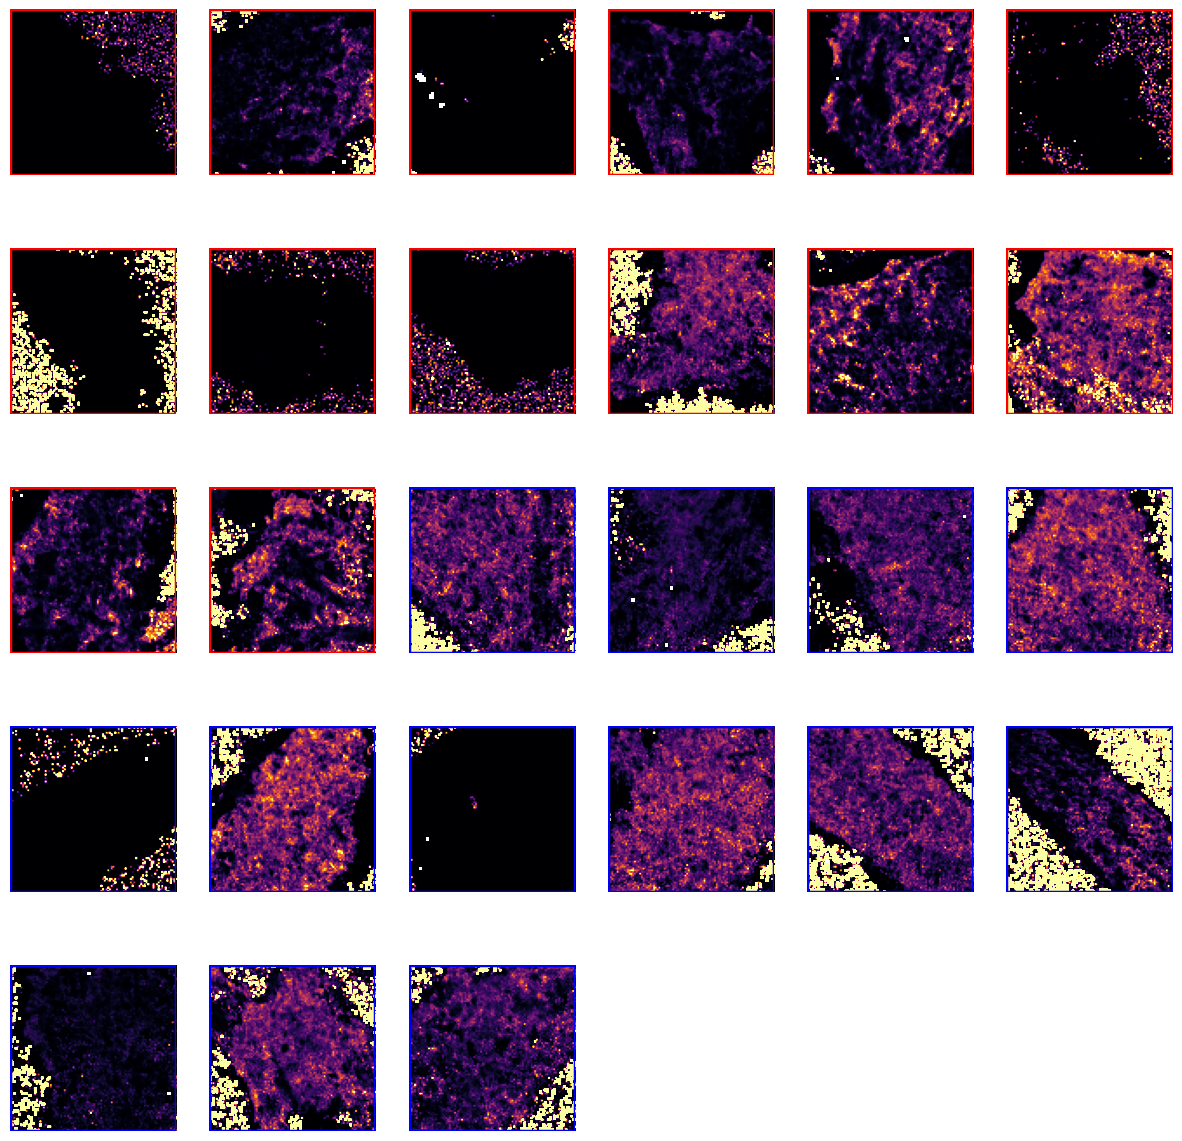

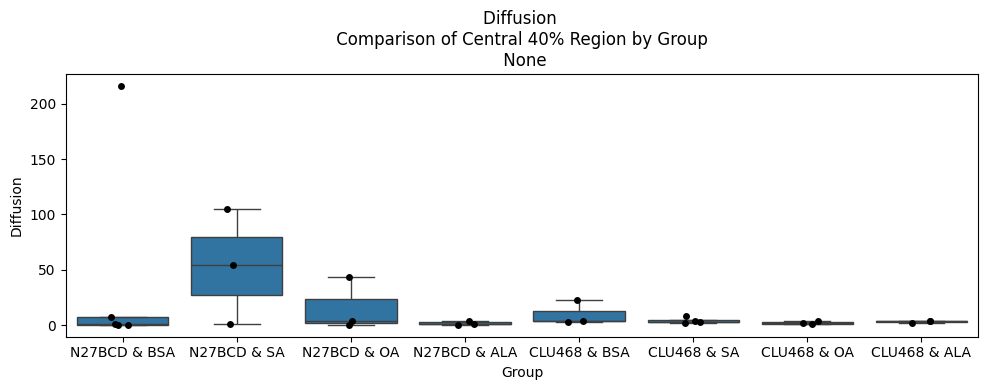

In [15]:
plt.close("all")
%matplotlib inline

diffusion_maps = get_p_map(param_array=array_parameter_map_all, mode=0, idx_param=2)

plot_d_values(param_array=diffusion_maps, list_basename=list_basename_all, mode=0, PARAM="Diffusion", central_fraction=CENTRAL_FRACTION)

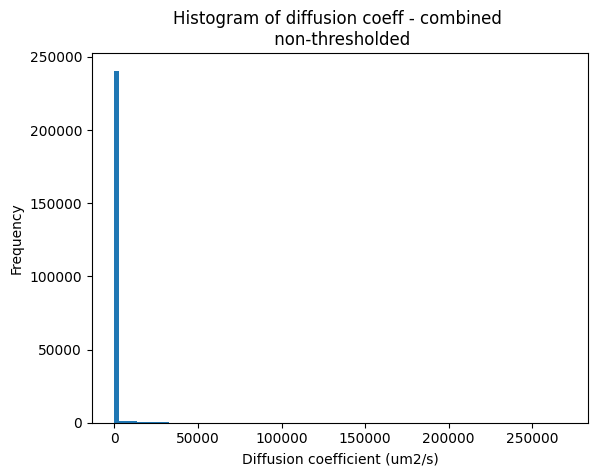

(27, 96, 96)


In [16]:
plt.hist(diffusion_maps.ravel(), bins=100)
# plt.xscale("log")
plt.xlabel("Diffusion coefficient (um2/s)")
plt.ylabel("Frequency")
plt.title(f"Histogram of diffusion coeff - combined \n non-thresholded")
plt.show()

print(diffusion_maps.shape)

Number of files: 27, width: 96, height: 96, number of parameters: 15
shape (27, 96, 96, 15)
shape (27, 96, 96)
pariwise t-test results:               N27BCD & BSA  N27BCD & SA  N27BCD & OA  N27BCD & ALA  \
N27BCD & BSA      1.000000     1.000000          1.0           1.0   
N27BCD & SA       1.000000     1.000000          1.0           1.0   
N27BCD & OA       1.000000     1.000000          1.0           1.0   
N27BCD & ALA      1.000000     1.000000          1.0           1.0   
CLU468 & BSA      1.000000     1.000000          1.0           1.0   
CLU468 & SA       0.031315     0.007826          1.0           1.0   
CLU468 & OA       1.000000     1.000000          1.0           1.0   
CLU468 & ALA      0.140226     0.160032          1.0           1.0   

              CLU468 & BSA  CLU468 & SA  CLU468 & OA  CLU468 & ALA  
N27BCD & BSA           1.0     0.031315          1.0      0.140226  
N27BCD & SA            1.0     0.007826          1.0      0.160032  
N27BCD & OA            1.0

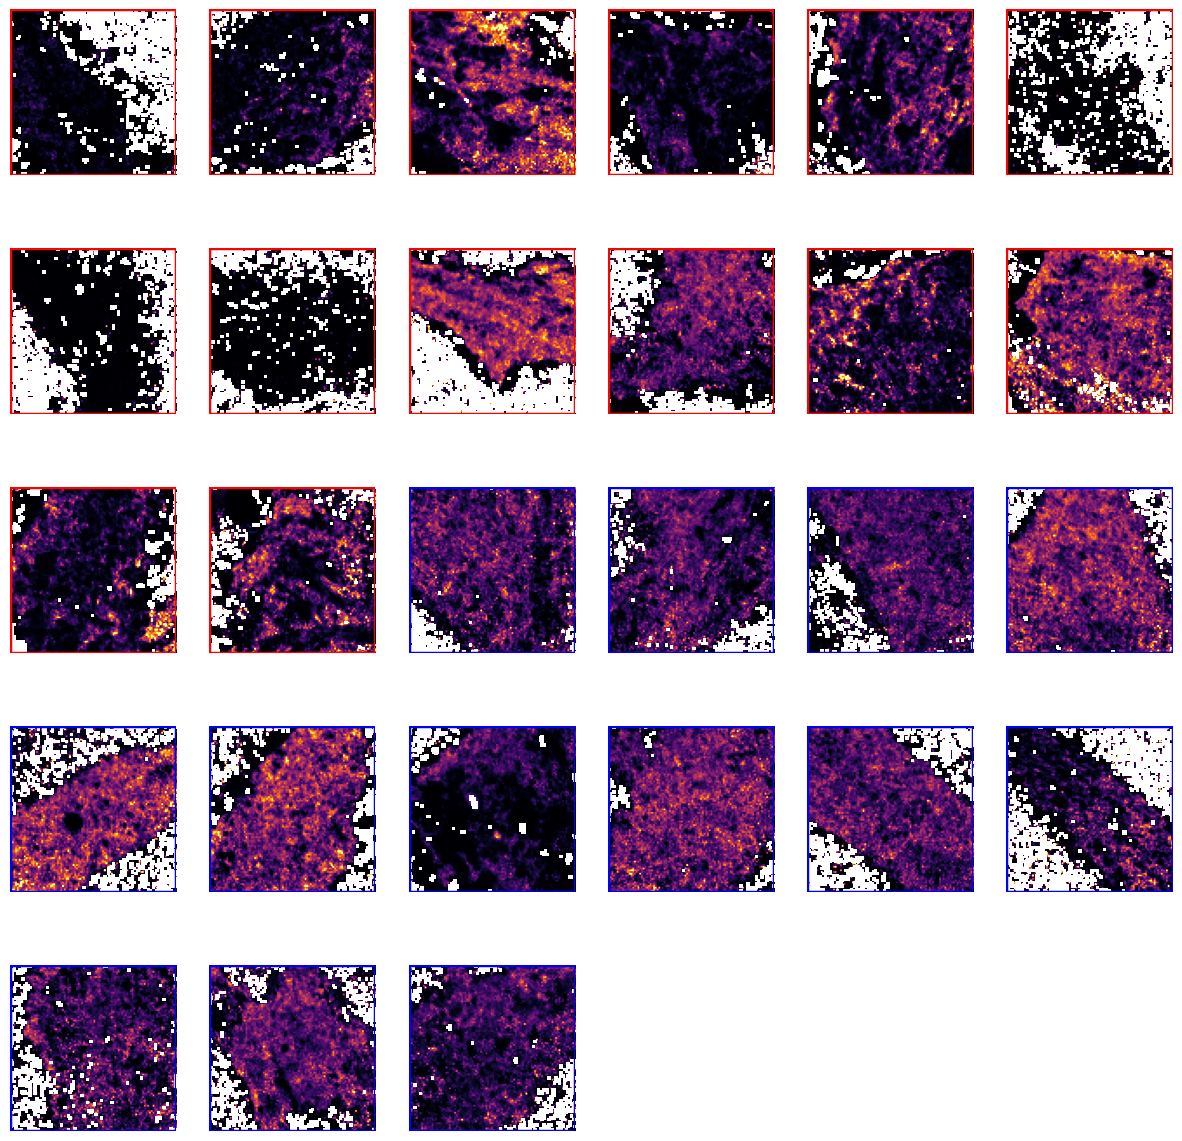

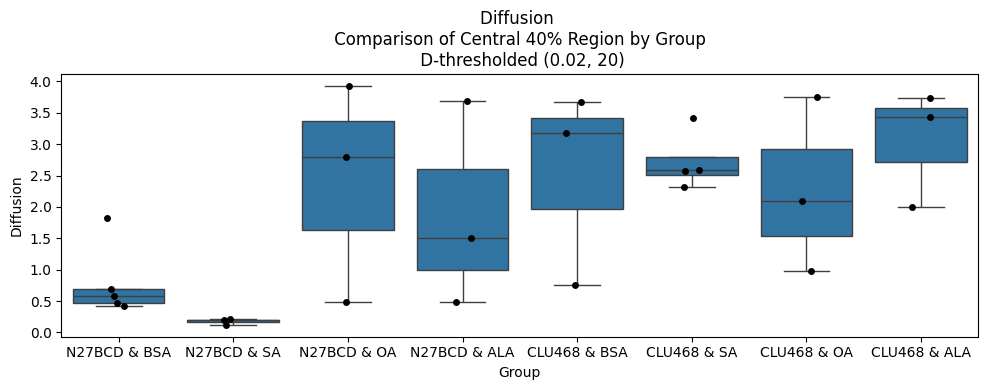

In [17]:
diffusion_maps_thres = get_p_map(
    param_array=array_parameter_map_all, mode=1, idx_param=2, d_threshold=D_THRESHOLD
)

plot_d_values(
    param_array=diffusion_maps_thres,
    list_basename=list_basename_all,
    mode=1,
    PARAM="Diffusion",
    title_suffix=f"D-thresholded {D_THRESHOLD}",
    central_fraction=CENTRAL_FRACTION,
)

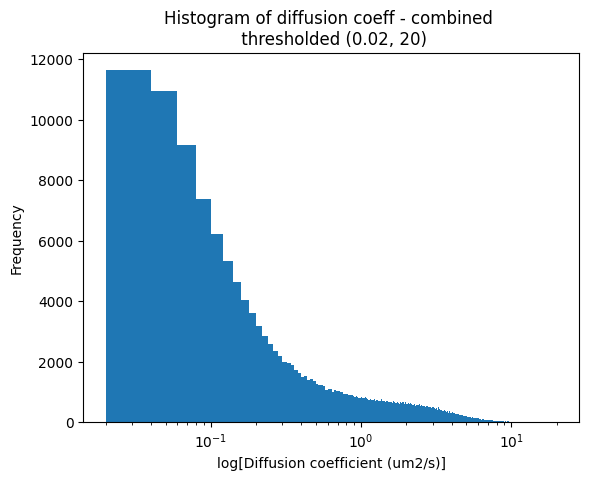

In [18]:
plt.hist(diffusion_maps_thres.ravel(), bins=1000)
plt.xscale("log")
plt.xlabel("log[Diffusion coefficient (um2/s)]")
plt.ylabel("Frequency")
plt.title(f"Histogram of diffusion coeff - combined \n thresholded {D_THRESHOLD}")
plt.show()